## Linear Regression Case Study

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [3]:
loans_df = pd.read_csv("loans.csv")

## Analyze Dataset

In [4]:
loans_df.head()

,interest_rate,fico_range,amount_requested,amount_funded_by_investors,loan_length
0,8.90,735-739,20000.0,20000.0,36.0
1,12.12,715-719,19200.0,19200.0,36.0
2,21.98,690-694,35000.0,35000.0,60.0
3,9.99,695-699,10000.0,9975.0,36.0
4,11.71,695-699,12000.0,12000.0,36.0


In [5]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   interest_rate               2498 non-null   float64
 1   fico_range                  2498 non-null   object 
 2   amount_requested            2498 non-null   float64
 3   amount_funded_by_investors  2498 non-null   float64
 4   loan_length                 2498 non-null   float64
dtypes: float64(4), object(1)
memory usage: 97.7+ KB


In [6]:
loans_df.describe()

,interest_rate,amount_requested,amount_funded_by_investors,loan_length
count,2498.000000,2498.000000,2498.000000,2498.000000
mean,13.070368,12413.030424,12009.280661,41.265012
std,4.178007,7801.222483,7743.387861,9.933753
min,5.420000,1000.000000,-0.010000,36.000000
25%,10.160000,6000.000000,6000.000000,36.000000
50%,13.110000,10000.000000,10000.000000,36.000000
75%,15.800000,17000.000000,16000.000000,36.000000
max,24.890000,35000.000000,35000.000000,60.000000


In [7]:
loans_df.shape

(2498, 5)

## Make Changes to FICO Column

In [8]:
loans_df['fico_range'].str.split("-")

0       [735, 739]
1       [715, 719]
2       [690, 694]
3       [695, 699]
4       [695, 699]
           ...    
2493    [705, 709]
2494    [740, 744]
2495    [680, 684]
2496    [675, 679]
2497    [670, 674]
Name: fico_range, Length: 2498, dtype: object

In [9]:
loans_df["FICO Score"] = loans_df["fico_range"].str[0:3].astype(int)

In [10]:
loans_df.head()

,interest_rate,fico_range,amount_requested,amount_funded_by_investors,loan_length,FICO Score
0,8.90,735-739,20000.0,20000.0,36.0,735
1,12.12,715-719,19200.0,19200.0,36.0,715
2,21.98,690-694,35000.0,35000.0,60.0,690
3,9.99,695-699,10000.0,9975.0,36.0,695
4,11.71,695-699,12000.0,12000.0,36.0,695


In [11]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   interest_rate               2498 non-null   float64
 1   fico_range                  2498 non-null   object 
 2   amount_requested            2498 non-null   float64
 3   amount_funded_by_investors  2498 non-null   float64
 4   loan_length                 2498 non-null   float64
 5   FICO Score                  2498 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 117.2+ KB


## Identify Features and Target

In [12]:
X = loans_df.drop(["interest_rate", "fico_range"], axis=1)

y = loans_df["interest_rate"]

In [13]:
numeric_features = ["amount_requested", "amount_funded_by_investors", "loan_length", "FICO Score"]

## Split Training and Test Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [15]:
X_train

,amount_requested,amount_funded_by_investors,loan_length,FICO Score
1805,27000.0,26975.0,60.0,715
1260,9000.0,9000.0,36.0,675
1584,21000.0,21000.0,36.0,775
1557,2200.0,2200.0,36.0,770
65,5300.0,5300.0,36.0,725
...,...,...,...,...
1638,4800.0,4800.0,36.0,695
1095,9975.0,9975.0,36.0,720
1130,14000.0,14000.0,36.0,720
1294,17500.0,17500.0,36.0,810


In [16]:
X_test

,amount_requested,amount_funded_by_investors,loan_length,FICO Score
2293,10000.0,10000.0,36.0,660
1864,8000.0,8000.0,36.0,790
902,12500.0,12425.0,36.0,780
2239,12000.0,12000.0,36.0,720
1285,19000.0,18975.0,36.0,775
...,...,...,...,...
286,8000.0,7925.0,60.0,675
1567,2500.0,2500.0,36.0,705
705,16000.0,15925.0,36.0,780
1127,3300.0,3300.0,36.0,740


In [17]:
y_train

1805    18.55
1260    14.27
1584     7.62
1557     7.90
65       7.90
        ...  
1638    14.33
1095     7.90
1130    10.65
1294     7.90
860     10.99
Name: interest_rate, Length: 1873, dtype: float64

In [18]:
y_test

2293    17.27
1864     6.99
902      9.32
2239    11.14
1285    11.14
        ...  
286     18.75
1567    10.37
705      6.03
1127     5.99
423     15.80
Name: interest_rate, Length: 625, dtype: float64

## Preprocessing

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)]
)

In [20]:
preprocessor

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Building Pipeline

In [21]:
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

In [22]:
y_pred

array([16.04829678,  4.38267758,  5.87682147, 11.06858904,  7.21718566,
       14.1345596 , 10.44474438, 15.62286251, 19.03485849, 13.58584017,
       11.94465888, 13.54557773, 14.10884792,  7.05682307, 17.95028481,
       12.57821358,  9.28283083, 18.27471266, 21.05706556, 15.17222694,
       12.42766872, 13.88800795,  5.53545871, 19.40371559, 12.79776073,
       10.42027695, 11.63951659, 14.06538178, 15.33341719,  9.91122542,
       15.63502185, 12.38241992, 10.10037339, 14.18076944, 14.17214504,
       16.23121591, 13.85812218, 13.25876364, 11.35415887, 13.99177468,
        2.73321136, 15.11494392, 13.92702613, 20.22222854, 19.6547152 ,
       14.57259452, 15.4948742 , 20.435171  , 16.01370787, 22.62269899,
       12.29027412, 15.63322985,  4.04622384, 14.91848363, 13.69679856,
       12.29027412, 13.61711583, 11.29979634, 14.11186549, 12.98205235,
        9.91420203,  9.6620646 , 14.45277759, 14.9972134 ,  9.23192719,
        6.36061557,  9.93877589, 14.07292115,  6.13179969, 13.48

## Evaluate Model Performance

In [23]:
print("Root Means Squared Error:", root_mean_squared_error(y_test, y_pred))
print("\nMean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nR2 Score:", r2_score(y_test, y_pred))

Root Means Squared Error: 2.1053477735379382

Mean Absolute Error: 1.6116618062567594

R2 Score: 0.747768695621529


## Visualization

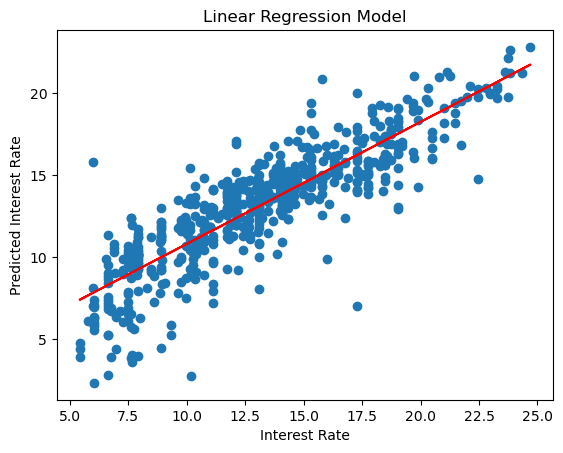

In [24]:
plt.scatter(y_test, y_pred)

plt.title("Linear Regression Model")
plt.xlabel("Interest Rate")
plt.ylabel("Predicted Interest Rate")

m, b = np.polyfit(y_test, y_pred, 1)

plt.plot(y_test, m * y_test + b, color='red', label=f'y = {m:.2f}x + {b:.2f}')

Text(0, 0.5, 'Residuals')

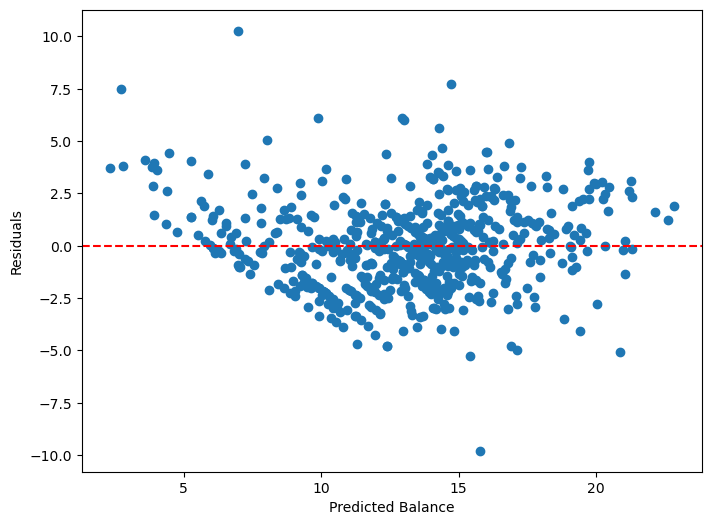

In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Balance")
plt.ylabel("Residuals")

In [26]:
feature_names = model_pipeline["preprocess"].get_feature_names_out()

# 2. Get coefficients
coefficients = model_pipeline["model"].coef_

# 3. Create table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# 4. Sort by absolute value
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

# Show top features
print(coef_df[["feature", "coefficient"]].head(10))

                           feature  coefficient
3                  num__FICO Score    -3.071336
2                 num__loan_length     1.361094
0            num__amount_requested     0.605580
1  num__amount_funded_by_investors     0.466947


In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor())
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

In [29]:
feature_names = model_pipeline.named_steps["preprocess"].get_feature_names_out()

# 2. Get feature importances from Random Forest
importances = model_pipeline.named_steps["model"].feature_importances_

# 3. Create table
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# 4. Sort by importance
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False)

# Show top features
print(feat_imp_df.head(10))

                           feature  importance
3                  num__FICO Score    0.611998
2                 num__loan_length    0.184179
1  num__amount_funded_by_investors    0.125411
0            num__amount_requested    0.078412


In [30]:
# importances = pd.Series(model_pipeline.feature_importances_, index=X.columns)
# importances = importances.sort_values(ascending=False)


In [31]:
print("Root Means Squared Error:", root_mean_squared_error(y_test, y_pred))
print("\nMean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nR2 Score:", r2_score(y_test, y_pred))

Root Means Squared Error: 2.1735831306133875

Mean Absolute Error: 1.5737560807103335

R2 Score: 0.7311538604505927


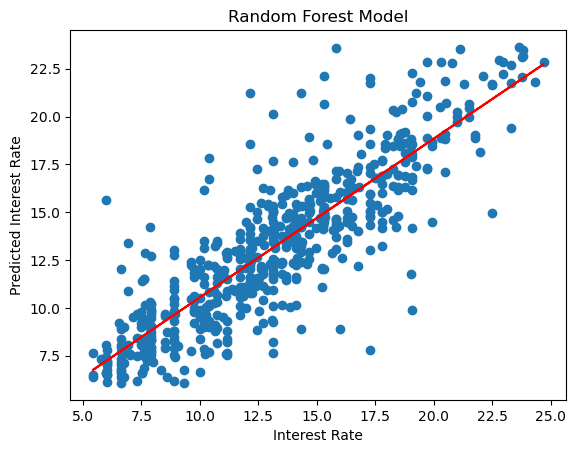

In [32]:
plt.scatter(y_test, y_pred)

plt.title("Random Forest Model")
plt.xlabel("Interest Rate")
plt.ylabel("Predicted Interest Rate")

m, b = np.polyfit(y_test, y_pred, 1)

plt.plot(y_test, m * y_test + b, color='red', label=f'y = {m:.2f}x + {b:.2f}')

Text(0, 0.5, 'Residuals')

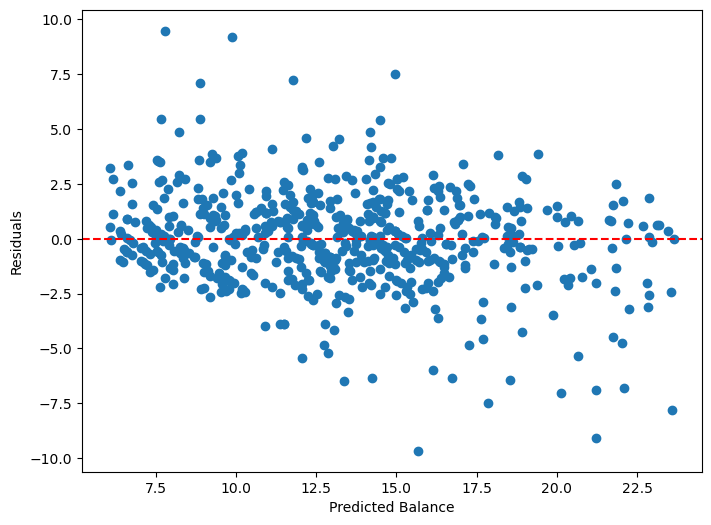

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Balance")
plt.ylabel("Residuals")

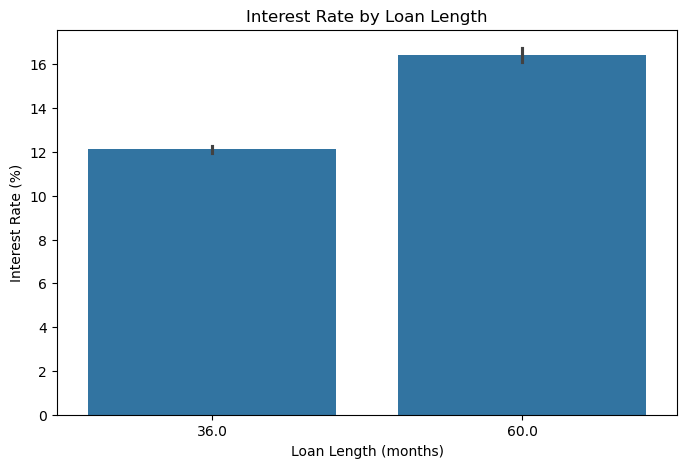

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x=loans_df["loan_length"], y=loans_df["interest_rate"])
plt.xlabel("Loan Length (months)")
plt.ylabel("Interest Rate (%)")
plt.title("Interest Rate by Loan Length")
plt.show()

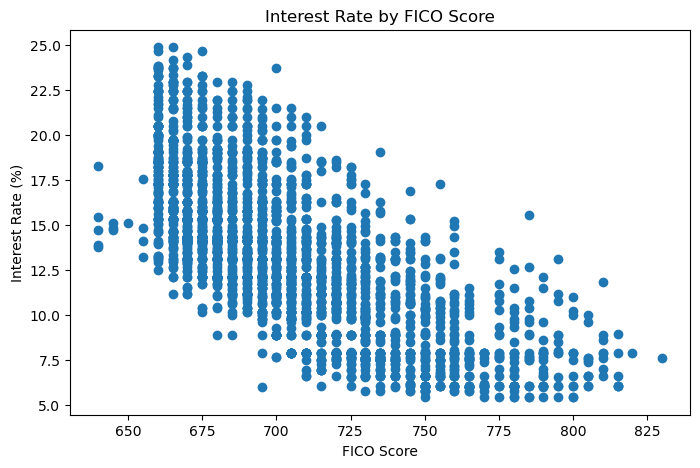

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(loans_df["FICO Score"], loans_df["interest_rate"])
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate (%)")
plt.title("Interest Rate by FICO Score")
plt.show()

In [36]:
from scipy.stats import ttest_ind

fico_60 = loans_df.loc[loans_df["loan_length"] == 60, "FICO Score"]
fico_36 = loans_df.loc[loans_df["loan_length"] == 36, "FICO Score"]

t_stat, p_two_sided = ttest_ind(fico_60, fico_36, equal_var=False)

# convert to one-sided p-value for: mean_60 > mean_36
if t_stat > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - (p_two_sided / 2)

print("t-statistic:", t_stat)
print("one-sided p-value:", p_one_sided)

print("Mean FICO for 60-month loans:", fico_60.mean())
print("Mean FICO for 36-month loans:", fico_36.mean())

t-statistic: 0.646569062795835
one-sided p-value: 0.25903769268217486
Mean FICO for 60-month loans: 706.6970802919708
Mean FICO for 36-month loans: 705.623076923077
